# Fase 4: Interpretabilidad, Simulación y Robustez

Notebook único de orquestación (D-13, `04-CONTEXT.md`) que ejecuta, en orden: (1) simulación contrafactual por bootstrap de bloques por país (INTERP-01/02), (2) heterogeneidad regional/por tipología vía términos de interacción (INTERP-03), y (3) interpretabilidad SHAP/VIF/PDP sobre un RandomForest auxiliar (INTERP-04/05/06), todo contra los datos reales de `data/panel.db`. Serializa `data/modelos/rf_shap_model.pkl` (D-08) y demuestra reproducibilidad de extremo a extremo (REPRO-02).

In [1]:
import sys
from pathlib import Path

# Notebook lives in notebook/, but `src/` and `data/panel.db` are relative to
# the project root -- add the project root to sys.path and chdir there so
# this notebook runs correctly regardless of launch method (nbconvert,
# Jupyter Lab, VS Code) or invocation cwd. Identical bootstrap pattern to
# notebook/3_1_modelo1_pib.ipynb.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import db, interpret, panel_base, simulate

DEP_VAR = "8.1.1"
INDEP_VARS = ["6.4.2"]
SEED = 42  # REPRO-02: single project-wide constant, threaded through every stochastic step

engine = db.get_engine(str(PROJECT_ROOT / "data" / "panel.db"))


In [2]:
# Full-table reads (no LIMIT) -- 03-RESEARCH.md Finding 3: a LIMIT-sampled
# read can misleadingly show object dtype on sparser indicator columns.
panel_clean = pd.read_sql("SELECT * FROM panel_clean", engine)
panel_exclusions = pd.read_sql("SELECT * FROM panel_exclusions", engine)

print("panel_clean shape:", panel_clean.shape)
print("panel_exclusions shape:", panel_exclusions.shape)


panel_clean shape: (4923, 12)
panel_exclusions shape: (529, 7)


In [3]:
filtered = panel_base.filter_by_exclusions(
    panel_clean, panel_exclusions, dep_var=DEP_VAR, indep_vars=INDEP_VARS
)

n_countries = filtered["country_code"].nunique()
n_obs = len(filtered)

# 03-RESEARCH.md Finding 4 / 04-RESEARCH.md expectation: ~171 countries, ~3,879 observations.
EXPECTED_COUNTRIES = 171
EXPECTED_OBS = 3879
country_drift = abs(n_countries - EXPECTED_COUNTRIES) / EXPECTED_COUNTRIES
obs_drift = abs(n_obs - EXPECTED_OBS) / EXPECTED_OBS

print(f"Countries after filter_by_exclusions: {n_countries} (expected ~{EXPECTED_COUNTRIES}, drift {country_drift:.1%})")
print(f"Observations after filter_by_exclusions: {n_obs} (expected ~{EXPECTED_OBS}, drift {obs_drift:.1%})")

if country_drift > 0.10 or obs_drift > 0.10:
    display(Markdown(
        f"**ALERTA:** la muestra se desvía más de un 10% de la expectativa de "
        f"03-RESEARCH.md Finding 4 (países: {country_drift:.1%}, observaciones: "
        f"{obs_drift:.1%}). Investigar antes de continuar -- no proceder "
        "silenciosamente sobre una discrepancia grande."
    ))
else:
    display(Markdown(
        f"Tamaño muestral confirmado dentro del 10% de la expectativa de "
        f"Finding 4: **{n_countries} países**, **{n_obs} observaciones** "
        f"(países: {country_drift:.1%} de desvío, observaciones: {obs_drift:.1%} de desvío)."
    ))


Countries after filter_by_exclusions: 171 (expected ~171, drift 0.0%)
Observations after filter_by_exclusions: 3933 (expected ~3879, drift 1.4%)


Tamaño muestral confirmado dentro del 10% de la expectativa de Finding 4: **171 países**, **3933 observaciones** (países: 0.0% de desvío, observaciones: 1.4% de desvío).

## Modelo base (Fase 3): carga de `model1_gdp.pkl`

Se carga, en modo solo lectura, el modelo de efectos fijos bidireccionales ya ajustado y serializado en la Fase 3 (`notebook/3_1_modelo1_pib.ipynb`). Este notebook NO reajusta ese modelo base sobre los datos reales -- se usa únicamente como referencia (`fitted_results`) para la simulación contrafactual; cada réplica del bootstrap reajusta su propio `fit_panel_model` internamente (`src/simulate.py`, D-12).

In [4]:
model1_path = PROJECT_ROOT / "data" / "modelos" / "model1_gdp.pkl"
with open(model1_path, "rb") as f:
    model1_fitted_results = pickle.load(f)

print("Modelo base (Fase 3) cargado desde:", model1_path)
print(model1_fitted_results.params)


Modelo base (Fase 3) cargado desde: C:\Users\olbap\source\repos\TFB\data\modelos\model1_gdp.pkl
6.4.2   -0.000139
Name: parameter, dtype: float64


## Simulación contrafactual (INTERP-01/02)

**Enmarcado explícito:** lo que sigue es un **análisis de sensibilidad**, no una predicción causal. `linearmodels` no admite predicción fuera de muestra con efectos de entidad/tiempo (04-RESEARCH.md, Pitfall #3) -- el efecto de cada escenario se calcula como el efecto marginal `coeficiente_réplica × Δestrés_hídrico`, nunca como un nivel absoluto predicho. El bootstrap remuestrea países completos con reemplazo (block bootstrap por entidad, D-01), respetando la dependencia temporal intra-país y la dependencia transversal que el test de Pesaran CD detectó en la Fase 3 (p=0.0014, `03-VERIFICATION.md`).

Cada escenario reduce el valor de estrés hídrico (`6.4.2`) del último año observado por país (2022, D-03) en -10%/-20%/-30%. La verificación de no-extrapolación (D-04) EXCLUYE -- nunca trunca -- un país de un escenario si su valor simulado cae por debajo del mínimo histórico global observado en el panel 2000-2022. `n_replicas=1000` por escenario (D-02), semillas fijas via `numpy.random.SeedSequence(SEED)` (REPRO-02).

In [5]:
REDUCTION_PCTS = [-0.10, -0.20, -0.30]

bootstrap_results = simulate.bootstrap_counterfactual(
    model1_fitted_results,
    filtered,
    DEP_VAR,
    "6.4.2",
    reduction_pcts=REDUCTION_PCTS,
    baseline_year=2022,
    n_replicas=1000,
    seed=SEED,
)

for pct, res in bootstrap_results.items():
    print(
        f"pct={pct:.0%}: effect_draws shape={res['effect_draws'].shape}, "
        f"n_excluded={len(res['excluded_countries'])}"
    )


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


...

C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


pct=-10%: effect_draws shape=(1000, 170), n_excluded=1
pct=-20%: effect_draws shape=(1000, 170), n_excluded=1
pct=-30%: effect_draws shape=(1000, 170), n_excluded=1


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


### Países excluidos por escenario (no-extrapolación, D-04)

Documentación explícita, por escenario, del número y la lista de países excluidos por caer por debajo del mínimo histórico global de estrés hídrico observado en el panel -- exigido explícitamente por D-04 ("debe documentarse explícitamente"), siguiendo la misma convención de alerta en `display(Markdown(...))` usada arriba para el chequeo de deriva muestral.

In [6]:
for pct in REDUCTION_PCTS:
    excluded = bootstrap_results[pct]["excluded_countries"]
    n_total = filtered["country_code"].nunique()
    if excluded:
        display(Markdown(
            f"**Escenario {pct:.0%}:** {len(excluded)} de {n_total} países "
            f"excluidos por no-extrapolación (D-04) -- su nivel simulado de "
            f"estrés hídrico caería por debajo del mínimo histórico global "
            f"2000-2022. Países excluidos: {sorted(excluded)}"
        ))
    else:
        display(Markdown(
            f"**Escenario {pct:.0%}:** 0 de {n_total} países excluidos -- "
            "ningún país cae por debajo del mínimo histórico global bajo "
            "este escenario."
        ))


**Escenario -10%:** 1 de 171 países excluidos por no-extrapolación (D-04) -- su nivel simulado de estrés hídrico caería por debajo del mínimo histórico global 2000-2022. Países excluidos: ['COG']

**Escenario -20%:** 1 de 171 países excluidos por no-extrapolación (D-04) -- su nivel simulado de estrés hídrico caería por debajo del mínimo histórico global 2000-2022. Países excluidos: ['COG']

**Escenario -30%:** 1 de 171 países excluidos por no-extrapolación (D-04) -- su nivel simulado de estrés hídrico caería por debajo del mínimo histórico global 2000-2022. Países excluidos: ['COG']

### Gráfico multi-escenario de sensibilidad (INTERP-02)

Para cada escenario se resume la distribución bootstrap del efecto marginal promedio (promediado entre los países que sobreviven la verificación de no-extrapolación de ESE escenario, por réplica) con su intervalo de confianza percentil 2.5/97.5 -- **análisis de sensibilidad, no predicción causal.**

,pct,mean_effect,ci_2.5,ci_97.5
0,-0.1,0.024019,-0.000364,0.133014
1,-0.2,0.048037,-0.000729,0.266028
2,-0.3,0.072056,-0.001093,0.399042


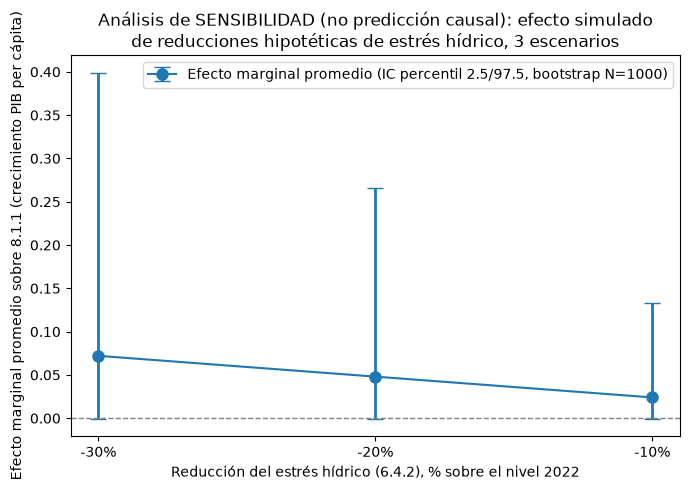

In [7]:
scenario_summary = []
for pct in REDUCTION_PCTS:
    effect_draws = bootstrap_results[pct]["effect_draws"]
    # Mean effect across surviving countries, per replica -- then percentile
    # CI across replicas (respects the bootstrap's own replica-to-replica
    # variance, not a single replica's own SE).
    avg_per_replica = effect_draws.mean(axis=1)
    scenario_summary.append({
        "pct": pct,
        "mean_effect": float(avg_per_replica.mean()),
        "ci_2.5": float(np.percentile(avg_per_replica, 2.5)),
        "ci_97.5": float(np.percentile(avg_per_replica, 97.5)),
    })

scenario_df = pd.DataFrame(scenario_summary)
display(scenario_df)

fig, ax = plt.subplots(figsize=(7, 5))
x = [s["pct"] * 100 for s in scenario_summary]
y = [s["mean_effect"] for s in scenario_summary]
yerr_low = [s["mean_effect"] - s["ci_2.5"] for s in scenario_summary]
yerr_high = [s["ci_97.5"] - s["mean_effect"] for s in scenario_summary]

ax.errorbar(
    x, y, yerr=[yerr_low, yerr_high], fmt="o-", capsize=6, color="tab:blue",
    ecolor="tab:blue", elinewidth=2, markersize=8,
    label="Efecto marginal promedio (IC percentil 2.5/97.5, bootstrap N=1000)",
)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Reducción del estrés hídrico (6.4.2), % sobre el nivel 2022")
ax.set_ylabel(f"Efecto marginal promedio sobre {DEP_VAR} (crecimiento PIB per cápita)")
ax.set_title(
    "Análisis de SENSIBILIDAD (no predicción causal): efecto simulado\n"
    "de reducciones hipotéticas de estrés hídrico, 3 escenarios"
)
ax.legend(loc="best")
ax.set_xticks(x)
ax.set_xticklabels([f"{p:.0%}" for p in REDUCTION_PCTS])
plt.tight_layout()
plt.show()


## Heterogeneidad regional / por tipología (INTERP-03)

**Enmarcado explícito (D-11):** los resultados se presentan Únicamente como tablas de coeficientes de interacción por grupo (`region`, `is_ldc`), con su error estándar e intervalo de confianza. **En ningún punto de esta sección se genera ni se muestra un valor predicho para un país individual** -- solo el coeficiente de la interacción `estrés_hídrico : grupo` dentro del mismo `PanelOLS` de efectos fijos bidireccionales (D-09). `fit_interaction_model` (`src/simulate.py`, Plan 04-01) omite deliberadamente el efecto principal `C(group)` -- es invariante en el tiempo por país y queda absorbido por `EntityEffects`, lo que provocaría `AbsorbingEffectError` si se incluyera (04-RESEARCH.md Pattern 2, verificado en vivo).

In [8]:
def interaction_coef_table(res, group_col):
    """Build a coefficient/SE/CI table restricted to the interaction
    terms (drops the lone Intercept row) -- D-11: coefficient table only,
    never a per-country prediction."""
    params = res.params
    interaction_terms = [p for p in params.index if p != "Intercept"]
    ci = res.conf_int()
    table = pd.DataFrame({
        "term": interaction_terms,
        "coef": params[interaction_terms].values,
        "std_error": res.std_errors[interaction_terms].values,
        "ci_lower": ci.loc[interaction_terms, "lower"].values,
        "ci_upper": ci.loc[interaction_terms, "upper"].values,
        "pvalue": res.pvalues[interaction_terms].values,
    })
    print(f"Interaction model: {DEP_VAR} ~ 6.4.2 : C({group_col}) + EntityEffects + TimeEffects")
    return table


In [9]:
region_interaction_fit = simulate.fit_interaction_model(
    filtered, DEP_VAR, "6.4.2", group_col="region",
)
region_table = interaction_coef_table(region_interaction_fit, "region")
display(region_table)


Interaction model: 8.1.1 ~ 6.4.2 : C(region) + EntityEffects + TimeEffects


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


,term,coef,std_error,ci_lower,ci_upper,pvalue
0,Q('6.4.2'):C(region)[Central and Southern Asia],0.012024,0.027574,-0.042039,0.066086,0.662824
1,Q('6.4.2'):C(region)[Eastern and South-Eastern...,-0.001412,0.001139,-0.003646,0.000821,0.215177
2,Q('6.4.2'):C(region)[Europe],0.040171,0.044565,-0.047203,0.127544,0.367431
3,Q('6.4.2'):C(region)[Europe and Northern America],-0.231406,0.152680,-0.530752,0.067940,0.129699
4,Q('6.4.2'):C(region)[Latin America and the Car...,-0.037555,0.022429,-0.081529,0.006419,0.094133
5,Q('6.4.2'):C(region)[Northern Africa and Weste...,-0.000134,0.000171,-0.000469,0.000201,0.433846
6,Q('6.4.2'):C(region)[Oceania],0.095069,0.205448,-0.307734,0.497872,0.643577
7,Q('6.4.2'):C(region)[Sub-Saharan Africa],-0.041239,0.034932,-0.109727,0.027250,0.237862


In [10]:
is_ldc_interaction_fit = simulate.fit_interaction_model(
    filtered, DEP_VAR, "6.4.2", group_col="is_ldc",
)
is_ldc_table = interaction_coef_table(is_ldc_interaction_fit, "is_ldc")
display(is_ldc_table)


C:\Users\olbap\source\repos\TFB\.venv\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


Interaction model: 8.1.1 ~ 6.4.2 : C(is_ldc) + EntityEffects + TimeEffects


,term,coef,std_error,ci_lower,ci_upper,pvalue
0,Q('6.4.2'):C(is_ldc)[0],-0.000104,0.000133,-0.000365,0.000157,0.434314
1,Q('6.4.2'):C(is_ldc)[1],-0.099155,0.034337,-0.166477,-0.031832,0.003904


**Nota metodológica:** las dos tablas anteriores muestran únicamente el coeficiente de la interacción estrés hídrico × grupo (región, tipología ONU `is_ldc`), con su error estándar y su intervalo de confianza al 95%. No se genera ningún valor predicho individual por país en ningún momento de esta sección -- es una limitación de diseño deliberada (D-11), no una omisión.

## Interpretabilidad: VIF/correlación, SHAP, PDP (INTERP-04/05/06)

Orden obligatorio (INTERP-04, precedencia): primero la tabla de VIF/correlación de los tres predictores numéricos del RandomForest auxiliar (`6.4.2`, `6.4.1`, `8.2.1`), reproduciendo los números reales de la Fase 2 (`notebook/2_1_construccion_panel_eda.ipynb`, celda 13) -- **antes** de cualquier salida de SHAP.

In [11]:
INDICATOR_COLS = ["6.4.2", "6.4.1", "8.1.1", "8.2.1", "2.3.1"]

# Reproduce Phase 2's exact listwise-complete-case VIF/correlation matrix
# (notebook/2_1_construccion_panel_eda.ipynb cell 13): complete-case across
# ALL 5 indicators (n=171 rows, since 2.3.1 has 96.5% missingness), NOT the
# RF's own 3473-row/3-predictor complete-case subset used below for SHAP.
global_corr = panel_clean[INDICATOR_COLS].dropna().corr()
global_vif = interpret.compute_vif_table(panel_clean, INDICATOR_COLS)

print("=== Matriz de correlación global (Fase 2, n=171 filas completas en los 5 indicadores) ===")
display(global_corr)
print("=== Tabla de VIF global (Fase 2) ===")
display(global_vif)


=== Matriz de correlación global (Fase 2, n=171 filas completas en los 5 indicadores) ===


,6.4.2,6.4.1,8.1.1,8.2.1,2.3.1
6.4.2,1.000000,-0.091718,-0.064395,-0.035367,0.268430
6.4.1,-0.091718,1.000000,-0.050035,-0.010378,0.347995
8.1.1,-0.064395,-0.050035,1.000000,0.703182,-0.316975
8.2.1,-0.035367,-0.010378,0.703182,1.000000,-0.208025
2.3.1,0.268430,0.347995,-0.316975,-0.208025,1.000000


=== Tabla de VIF global (Fase 2) ===


,variable,VIF
0,6.4.2,1.126749
1,6.4.1,1.195427
2,8.1.1,2.107345
3,8.2.1,1.981170
4,2.3.1,1.409088


In [12]:
predictors_num = ["6.4.2", "6.4.1", "8.2.1"]
predictor_corr = global_corr.loc[predictors_num, predictors_num]
max_abs_corr_predictors = (
    predictor_corr.where(~np.eye(len(predictors_num), dtype=bool)).abs().max().max()
)
max_predictor_vif = global_vif.set_index("variable").loc[predictors_num, "VIF"].max()

display(Markdown(
    f"**Aviso de sesgo por correlación (INTERP-04):** entre los tres "
    f"predictores numéricos del RandomForest auxiliar (`6.4.2`, `6.4.1`, "
    f"`8.2.1`), la correlación máxima en valor absoluto es "
    f"**|r|={max_abs_corr_predictors:.3f}** y el VIF máximo es "
    f"**{max_predictor_vif:.3f}** (ambos números reales de la Fase 2, no "
    "genéricos) -- solo **multicolinealidad modesta** globalmente entre "
    "estos tres predictores. La correlación más fuerte de toda la matriz "
    f"(r={global_corr.loc['8.1.1','8.2.1']:.3f}) es entre `8.2.1` y la "
    "variable DEPENDIENTE `8.1.1`, no entre predictores. Aun así, el sesgo "
    "por correlación de SHAP aplica en principio siempre que exista "
    "cualquier correlación entre predictores, y el VIF por subgrupo "
    "regional (calculado en la Fase 2, celdas 14-15) es mucho más alto "
    "para algunas regiones (p. ej. Latinoamérica y el Caribe muestra VIF "
    ">70-300 para varios indicadores) -- una limitación real que este "
    "RandomForest global agrupado no captura, aunque no afecte de forma "
    "relevante a los tres predictores efectivamente usados aquí."
))


**Aviso de sesgo por correlación (INTERP-04):** entre los tres predictores numéricos del RandomForest auxiliar (`6.4.2`, `6.4.1`, `8.2.1`), la correlación máxima en valor absoluto es **|r|=0.092** y el VIF máximo es **1.981** (ambos números reales de la Fase 2, no genéricos) -- solo **multicolinealidad modesta** globalmente entre estos tres predictores. La correlación más fuerte de toda la matriz (r=0.703) es entre `8.2.1` y la variable DEPENDIENTE `8.1.1`, no entre predictores. Aun así, el sesgo por correlación de SHAP aplica en principio siempre que exista cualquier correlación entre predictores, y el VIF por subgrupo regional (calculado en la Fase 2, celdas 14-15) es mucho más alto para algunas regiones (p. ej. Latinoamérica y el Caribe muestra VIF >70-300 para varios indicadores) -- una limitación real que este RandomForest global agrupado no captura, aunque no afecte de forma relevante a los tres predictores efectivamente usados aquí.

### RandomForest auxiliar + SHAP (INTERP-04, D-05/D-06/D-07/D-08)

Predictores (D-05): `6.4.2` (estrés hídrico), `6.4.1` (eficiencia del agua), `8.2.1` (productividad laboral) + tipología de país (`is_ldc`, `is_lldc`, `is_sids`, `region` one-hot). `2.3.1` se excluye deliberadamente de los predictores (D-06). El mismo RandomForest se reutiliza como métrica predictiva de referencia (`oob_score_`, INTERP-06, D-07) -- no se entrena un modelo separado.

In [13]:
FEATURE_VARS = ["6.4.2", "6.4.1", "8.2.1", "is_ldc", "is_lldc", "is_sids", "region"]

rf, shap_values, X_rf, explainer = interpret.shap_analysis(
    panel_clean, DEP_VAR, FEATURE_VARS, seed=SEED,
)

print(f"RF entrenado sobre {len(X_rf)} filas completas (de {len(panel_clean)} totales)")
print(f"Matriz de features X: {X_rf.shape}")
print(f"SHAP values: {shap_values.shape}")


RF entrenado sobre 3473 filas completas (de 4923 totales)
Matriz de features X: (3473, 13)
SHAP values: (3473, 13)


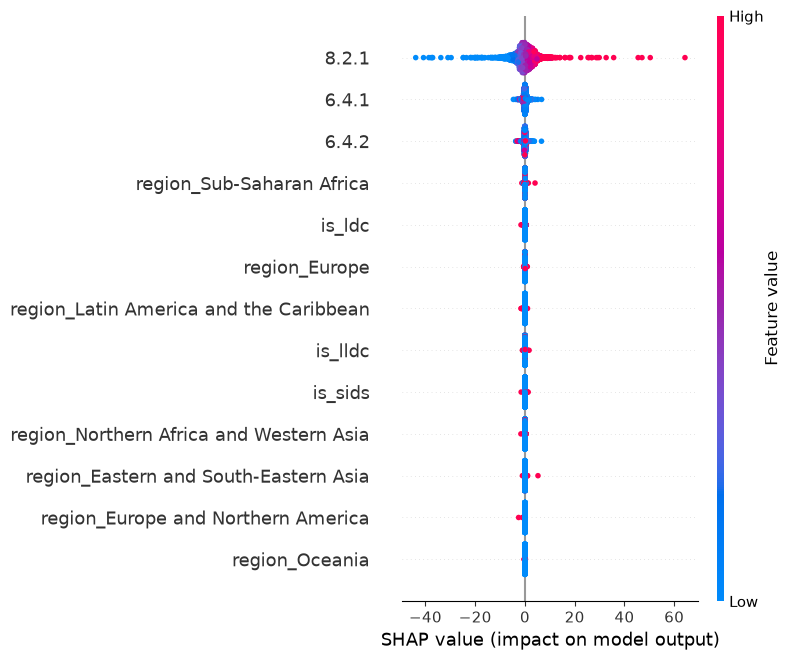

In [14]:
import shap

shap.summary_plot(shap_values, X_rf, show=False)
plt.tight_layout()
plt.show()


### Métrica predictiva de referencia (INTERP-06, D-07)

In [15]:
display(Markdown(
    f"**Out-of-bag R² del RandomForest auxiliar (INTERP-06):** "
    f"`rf.oob_score_` = **{rf.oob_score_:.4f}**. Se reporta como métrica "
    "predictiva complementaria del mismo RF ya usado para SHAP (D-07) -- "
    "no sustituye la interpretación causal de los modelos de panel de "
    "efectos fijos (Fase 3, sección de limitaciones), solo indica cuánta "
    "varianza de `8.1.1` explican estos predictores en un sentido "
    "puramente predictivo/no-causal."
))


**Out-of-bag R² del RandomForest auxiliar (INTERP-06):** `rf.oob_score_` = **0.6273**. Se reporta como métrica predictiva complementaria del mismo RF ya usado para SHAP (D-07) -- no sustituye la interpretación causal de los modelos de panel de efectos fijos (Fase 3, sección de limitaciones), solo indica cuánta varianza de `8.1.1` explican estos predictores en un sentido puramente predictivo/no-causal.

### Partial-dependence plots (INTERP-05)

Complementan SHAP para los predictores numéricos correlacionados identificados en la Fase 2 -- se elige `sklearn.inspection.PartialDependenceDisplay` (sin nueva dependencia; `PyALE` fue marcado `SUS` en la auditoría de legitimidad de `04-RESEARCH.md` y no se instaló, Plan 04-02). Se muestran los tres predictores numéricos del RF -- `8.2.1` tiene el VIF global más alto de los tres (Fase 2: 1.98) y es el más correlacionado con la variable dependiente (r=0.70), por lo que es el candidato más relevante a revisar con PDP; se incluyen también `6.4.2` y `6.4.1` para tener el conjunto completo de predictores numéricos del RF.

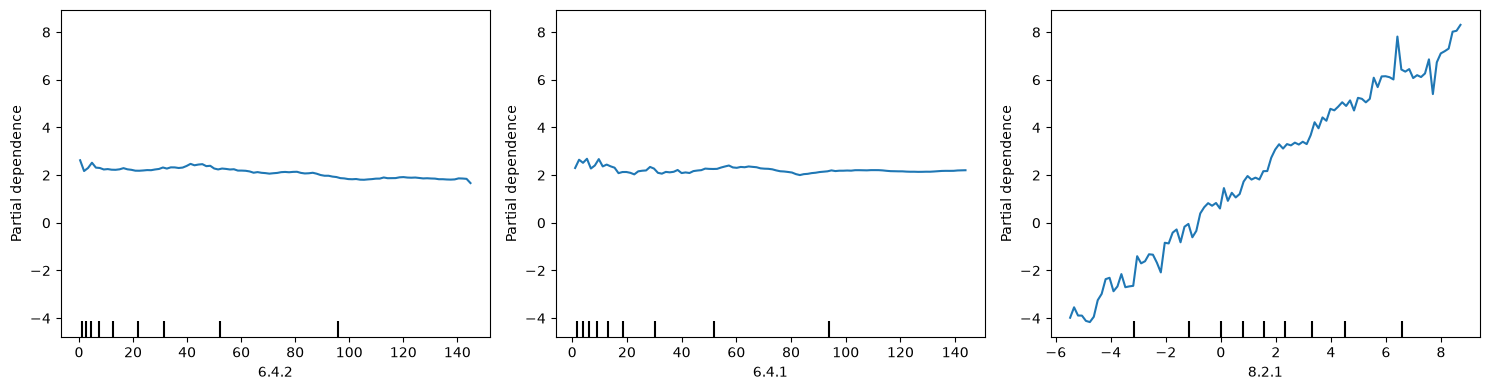

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
interpret.partial_dependence_plots(rf, X_rf, ["6.4.2", "6.4.1", "8.2.1"], ax=axes)
plt.tight_layout()
plt.show()


### Serialización de `data/modelos/rf_shap_model.pkl` (D-08)

Mismo patrón de serialización + verificación de round-trip ya establecido para `model1_gdp.pkl` (Fase 3, `notebook/3_1_modelo1_pib.ipynb`) -- "nunca confiar en un pickle no verificado". El `.pkl` es producido y consumido únicamente por el propio código de este proyecto (nunca cargado desde una ruta externa/no confiable), consistente con el invariante T-04-03 del registro de amenazas.

In [17]:
models_dir = PROJECT_ROOT / "data" / "modelos"
models_dir.mkdir(parents=True, exist_ok=True)
rf_model_path = models_dir / "rf_shap_model.pkl"

with open(rf_model_path, "wb") as f:
    pickle.dump(rf, f)
print(f"RandomForest auxiliar serializado en: {rf_model_path}")


RandomForest auxiliar serializado en: C:\Users\olbap\source\repos\TFB\data\modelos\rf_shap_model.pkl


In [18]:
with open(rf_model_path, "rb") as f:
    reloaded_rf = pickle.load(f)

importances_match = np.allclose(reloaded_rf.feature_importances_, rf.feature_importances_)
print("Las importancias de features del RF recargado coinciden con el RF en memoria:", importances_match)
assert importances_match, "El RF recargado desde .pkl no coincide con el RF ajustado en memoria"


Las importancias de features del RF recargado coinciden con el RF en memoria: True
